In [1]:
import pandas as pd
import numpy as np
import re
from plotnine import *
import patchworklib as pw
from tqdm import tqdm
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu, ttest_ind, fisher_exact

import seaborn as sns
from statsmodels.stats.multitest import multipletests
import os

os.chdir('/data2/core-med1/nhadizad/nastaran/Xenotransplant/global/some_R/v2')


plt.rcParams['pdf.fonttype'] = 42  # Ensures editable text in PDFs



# --- add this near the top (after imports) ---
COND_ORDER = [
    # "Control",
    "Standard protocol",
    "Extended protocol",
    # "Prematurely terminated",
    "PCMV",
    "Rejection",
]

COND_PALETTE = {
    # "Control": "#EFE48E",
    "Standard protocol": "skyblue",
    "Extended protocol": "#08528f",
    # "Prematurely terminated": "#C9B8D9",
    "PCMV": "#F0C096",
    "Rejection": "#E09E9E",
}


<Figure size 100x100 with 0 Axes>

In [2]:
import sklearn
print(sklearn.__version__)


1.7.0


In [2]:
# length_difference=pd.read_csv("/data2/core-med1/elindber/PROJECTS/20231020_el_Xenotransplant/PROTEOMICS_bqhn01/Pig_Baboon_Protlength_difference_20250409.csv")

In [4]:
Beads=pd.read_csv("/data2/core-med1/elindber/PROJECTS/20231020_el_Xenotransplant/PROTEOMICS_bqhn01/Lafuga_additional_info/Eric_xeno_beads_Genesmatrix_oldnames_atleast2peptides_speciesinformation_KNNIMPUTED.csv", sep=",")
#Beads=pd.read_csv("/data2/core-med1/elindber/PROJECTS/20231020_el_Xenotransplant/PROTEOMICS_bqhn01/Lafuga_additional_info/Eric_xeno_beads_Genesmatrix_oldnames_atleast2peptides_speciesinformation.txt", sep="\t")
#PCA=pd.read_csv("/data2/core-med1/elindber/PROJECTS/20231020_el_Xenotransplant/PROTEOMICS_bqhn01/Lafuga_additional_info/Eric_xeno_PCA_Genesmatrix_oldnames_atleast2peptides_speciesinformation.txt", sep="\t")
#Neat=pd.read_csv("/data2/core-med1/elindber/PROJECTS/20231020_el_Xenotransplant/PROTEOMICS_bqhn01/Lafuga_additional_info/Eric_xeno_Neat_Genesmatrix_oldnames_atleast2peptides_speciesinformation.txt", sep="\t")

In [6]:
# Read the CSV file
Beads = pd.read_csv("/data2/core-med1/elindber/PROJECTS/20231020_el_Xenotransplant/PROTEOMICS_bqhn01/Lafuga_additional_info/Eric_xeno_beads_Genesmatrix_oldnames_atleast2peptides_speciesinformation_KNNIMPUTED.csv", sep=",")

# Save the DataFrame to a new CSV file in your current working directory
output_file_path = 'Beads_data.csv'
Beads.to_csv(output_file_path, index=False)


In [8]:
import pandas as pd
import os
import re

# Set the working directory
os.chdir('/data2/core-med1/nhadizad/nastaran/Xenotransplant/global/some_R/v2')

# Read the CSV file
Beads = pd.read_csv("/data2/core-med1/elindber/PROJECTS/20231020_el_Xenotransplant/PROTEOMICS_bqhn01/Lafuga_additional_info/Eric_xeno_beads_Genesmatrix_oldnames_atleast2peptides_speciesinformation_KNNIMPUTED.csv", sep=",")

# Find the columns that represent Sample_IDs and their day values using a general pattern
sample_columns = [col for col in Beads.columns if re.match(r'^PAV\d{2}_-?\d+', col)]

# Create a dictionary to store the sample IDs and their day values
sample_days_dict = {}

for col in sample_columns:
    # Use a regular expression to extract the Sample ID (PAV followed by two digits) and the day value
    match = re.match(r'^(PAV\d{2})_(-?\d+)', col)
    if match:
        sample_id = match.group(1)
        day_value = match.group(2)
        
        # Check if the Sample_ID is already in the dictionary
        if sample_id not in sample_days_dict:
            sample_days_dict[sample_id] = []
        sample_days_dict[sample_id].append(day_value)

# Create a list of lists from the dictionary for the DataFrame
data = [[sample_id, ', '.join(sorted(day_values, key=int))] for sample_id, day_values in sample_days_dict.items()]

# Create a new DataFrame with 'Sample_ID' and 'Day_Values' columns
new_df = pd.DataFrame(data, columns=['Sample_ID', 'Day_Values'])

# Save the new DataFrame to a CSV file in your current working directory
output_file_path = 'all_sample_days_info.csv'
new_df.to_csv(output_file_path, index=False)

print(f"File saved successfully at: {os.path.abspath(output_file_path)}")

File saved successfully at: /data2/core-med1/nhadizad/nastaran/Xenotransplant/global/some_R/v2/all_sample_days_info.csv


In [11]:
# Read the original CSV file
Beads = pd.read_csv("/data2/core-med1/elindber/PROJECTS/20231020_el_Xenotransplant/PROTEOMICS_bqhn01/Lafuga_additional_info/Eric_xeno_beads_Genesmatrix_oldnames_atleast2peptides_speciesinformation_KNNIMPUTED.csv", sep=",")

# Define the list of specific columns to keep
# This includes the initial metadata columns and the requested sample columns.
columns_to_keep = [
    'Unnamed: 0', 'Genes', 'Protein.Ids', 'Organism', 'Species', 'n_peptides',
    'PAV65_86', 'PAV66_50', 'PAV67_90', 'PAV68_9', 'PAV69_90', 'PAV71_180',
    'PAV72_194', 'PAV73_9', 'PAV74_26', 'PAV75_90', 'PAV76_13', 'PAV78_50',
    'PAV79_28', 'PAV80_90', 'PAV82_90', 'PAV85_119', 'PAV86_180'
]

# Create a new DataFrame by selecting only the specified columns
final_day_data = Beads[columns_to_keep]

# Save the new DataFrame to a CSV file in your current working directory
output_file_path = 'final_endpoint_samples_info.csv'
final_day_data.to_csv(output_file_path, index=False)

print(f"File saved successfully at: {os.path.abspath(output_file_path)}")

File saved successfully at: /data2/core-med1/nhadizad/nastaran/Xenotransplant/global/some_R/v2/final_endpoint_samples_info.csv


In [15]:
import pandas as pd

# The dictionary that correctly maps each Sample_ID to its condition
sample_conditions_map = {
    'PAV66': 'Standard protocol',
    'PAV82': 'Standard protocol',
    'PAV75': 'Standard protocol',
    'PAV78': 'Rejection',
    'PAV72': 'Extended protocol',
    'PAV85': 'Extended protocol',
    'PAV65': 'Standard protocol',
    'PAV76': 'Rejection',
    'PAV71': 'Extended protocol',
    'PAV86': 'Rejection',
    'PAV68': 'PCMV',
    'PAV84': 'Prematurely terminated',
    'PAV73': 'PCMV',
    'PAV79': 'Rejection',
    'PAV74': 'PCMV',
    'PAV83': 'Prematurely terminated',
    'PAV67': 'Standard protocol',
    'PAV69': 'Standard protocol',
    'PAV80': 'Standard protocol'
}

# The Sample IDs you have in your dataset
# This list is derived from the 'PAVXX_YY' column names
sample_ids_with_day = [
    'PAV65_86', 'PAV66_50', 'PAV67_90', 'PAV68_9', 'PAV69_90', 'PAV71_180',
    'PAV72_194', 'PAV73_9', 'PAV74_26', 'PAV75_90', 'PAV76_13', 'PAV78_50',
    'PAV79_28', 'PAV80_90', 'PAV82_90', 'PAV85_119', 'PAV86_180'
]

# Extract just the base Sample IDs (e.g., 'PAV65') from the full column names
base_sample_ids = [sample_id.split('_')[0] for sample_id in sample_ids_with_day]

# Create a list of conditions that corresponds to the order of your columns
conditions_for_analysis = [sample_conditions_map.get(base_id, 'Unknown') for base_id in base_sample_ids]

# Now you have two lists that are perfectly aligned:
# 1. The list of your sample column names
# 2. The list of their corresponding conditions
print("Sample Columns:", sample_ids_with_day)
print("Conditions:", conditions_for_analysis)

# You can also create a DataFrame for a clean, table-like view
condition_df = pd.DataFrame({
    'Sample_ID_with_Day': sample_ids_with_day,
    'Condition': conditions_for_analysis
})

print("\nDataFrame of Samples and Conditions:")
print(condition_df)

Sample Columns: ['PAV65_86', 'PAV66_50', 'PAV67_90', 'PAV68_9', 'PAV69_90', 'PAV71_180', 'PAV72_194', 'PAV73_9', 'PAV74_26', 'PAV75_90', 'PAV76_13', 'PAV78_50', 'PAV79_28', 'PAV80_90', 'PAV82_90', 'PAV85_119', 'PAV86_180']
Conditions: ['Standard protocol', 'Standard protocol', 'Standard protocol', 'PCMV', 'Standard protocol', 'Extended protocol', 'Extended protocol', 'PCMV', 'PCMV', 'Standard protocol', 'Rejection', 'Rejection', 'Rejection', 'Standard protocol', 'Standard protocol', 'Extended protocol', 'Rejection']

DataFrame of Samples and Conditions:
   Sample_ID_with_Day          Condition
0            PAV65_86  Standard protocol
1            PAV66_50  Standard protocol
2            PAV67_90  Standard protocol
3             PAV68_9               PCMV
4            PAV69_90  Standard protocol
5           PAV71_180  Extended protocol
6           PAV72_194  Extended protocol
7             PAV73_9               PCMV
8            PAV74_26               PCMV
9            PAV75_90  Standar

In [171]:
df = pd.read_csv("/data2/core-med1/nhadizad/nastaran/Xenotransplant/global/some_R/v2/final_endpoint_samples_info.csv")
# df.head()


In [172]:
# Log normalization

sample_cols = [c for c in df.columns if c.startswith("PAV")]

df[sample_cols] = np.log2(df[sample_cols])
df[sample_cols] = df[sample_cols].sub(df[sample_cols].median(axis=0), axis=1)


In [27]:
import os

# path for saving
out_file = "/data2/core-med1/nhadizad/nastaran/Xenotransplant/global/some_R/v2/final_endpoint_samples_info_logNorm.csv"

# save the log-normalized dataframe
df.to_csv(out_file, index=False)



Start from here

In [3]:
df = pd.read_csv("/data2/core-med1/nhadizad/nastaran/Xenotransplant/global/some_R/v2/final_endpoint_samples_info_logNorm.csv")
# df.head()
sample_cols = [c for c in df.columns if c.startswith("PAV")]

In [4]:
condition_map = {
    'PAV66': 'Standard protocol',
    'PAV82': 'Standard protocol',
    'PAV75': 'Standard protocol',
    'PAV78': 'Rejection',
    'PAV72': 'Extended protocol',
    'PAV85': 'Extended protocol',
    'PAV65': 'Standard protocol',
    'PAV76': 'Rejection',
    'PAV71': 'Extended protocol',
    'PAV86': 'Rejection',
    'PAV68': 'PCMV',
    'PAV84': 'Prematurely terminated',
    'PAV73': 'PCMV',
    'PAV79': 'Rejection',
    'PAV74': 'PCMV',
    'PAV83': 'Prematurely terminated',
    'PAV67': 'Standard protocol',
    'PAV69': 'Standard protocol',
    'PAV80': 'Standard protocol'
}

meta = pd.DataFrame({
    "Sample": sample_cols,
    "Condition": [condition_map[s.split("_")[0]] for s in sample_cols]
})


In [5]:
# --- Main Plotting Function with Analysis and Saving ---
def plot_gene(gene):
    """
    Plots log-normalized gene expression, performs significance testing
    against 'Standard protocol', and saves the plot as a PDF.
    """
    # Filter the data and merge with metadata
    gene_data = df[df['Genes'] == gene][sample_cols].melt(var_name="Sample", value_name="Log2NormIntensity")
    gene_data = gene_data.merge(meta, on="Sample")
    
    # Filter for the conditions we care about for plotting
    plot_data = gene_data[gene_data['Condition'].isin(COND_ORDER)]

    # Significance testing
    comparisons = []
    p_values = []
    
    # Get the data for the 'Standard protocol' group
    std_protocol_data = plot_data[plot_data['Condition'] == 'Standard protocol']['Log2NormIntensity']

    # Compare each other condition against 'Standard protocol'
    for cond in COND_ORDER:
        if cond != "Standard protocol":
            test_data = plot_data[plot_data['Condition'] == cond]['Log2NormIntensity']
            
            # Check if both groups have enough data to perform the test
            if len(std_protocol_data) > 1 and len(test_data) > 1:
                try:
                    # Mann-Whitney U test (unpaired)
                    stat, p = mannwhitneyu(std_protocol_data, test_data, alternative='two-sided')
                    comparisons.append((cond, 'Standard protocol'))
                    p_values.append(p)
                except ValueError as e:
                    print(f"Skipping comparison {cond} vs Standard protocol due to error: {e}")
            
    # Apply Benjamini-Hochberg FDR correction
    if p_values:
        reject, p_adjusted, _, _ = multipletests(p_values, method='fdr_bh')
        significance = {comp: adj_p for comp, adj_p in zip(comparisons, p_adjusted)}
    else:
        significance = {}
        
    # Create the plot
    plt.figure(figsize=(4, 5))
    
    # Box plot - Changed alpha to make colors more bold
    sns.boxplot(data=plot_data, x="Condition", y="Log2NormIntensity",
                order=COND_ORDER, palette=COND_PALETTE, boxprops=dict(alpha=0.8))
    
    # Stripplot for individual data points
    sns.stripplot(data=plot_data, x="Condition", y="Log2NormIntensity", color="black", alpha=0.6,
                  order=COND_ORDER)
    
    # Add significance stars
    max_y = plot_data['Log2NormIntensity'].max()
    # Adjusted line_height to bring bars down slightly
    line_height = max_y + (max_y * 0.05) 
    
    for i, cond in enumerate(COND_ORDER):
        if cond != "Standard protocol":
            comp = (cond, 'Standard protocol')
            if comp in significance:
                adj_p = significance[comp]
                
                # Determine significance level
                stars = ""
                if adj_p < 0.001:
                    stars = "***"
                elif adj_p < 0.01:
                    stars = "**"
                elif adj_p < 0.05:
                    stars = "*"
                
                if stars:
                    # Get x-positions for the two groups
                    x1 = COND_ORDER.index('Standard protocol')
                    x2 = i
                    
                    # Add significance annotation
                    plt.text((x1 + x2) / 2, line_height, stars, ha='center', va='bottom',
                             fontsize=20, color='black')
                    
                    # Draw a line between the two groups
                    plt.plot([x1, x1, x2, x2],
                             [line_height - 0.05, line_height, line_height, line_height - 0.05],
                             lw=1.5, c='black')
                    
                    line_height += (max_y * 0.05) # Increment y-position for next comparison

    # Set plot labels and title
    plt.title(f"{gene} expression across conditions", fontsize=12)
    plt.xlabel("Condition", fontsize=12)
    plt.ylabel("Log2 Normalized Intensity", fontsize=12)
    plt.xticks(rotation=90, ha='center')
    plt.tight_layout()
    
    # Save the plot to the specified directory
    output_dir = "/data2/core-med1/nhadizad/nastaran/Xenotransplant/global/some_R/v2/Results"
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)
        print(f"Created directory: {output_dir}")
        
    plt.savefig(f"{output_dir}/{gene}.pdf", dpi=300)
    plt.show()

# # Example usage:
# plot_gene("MX1_PAPAN")


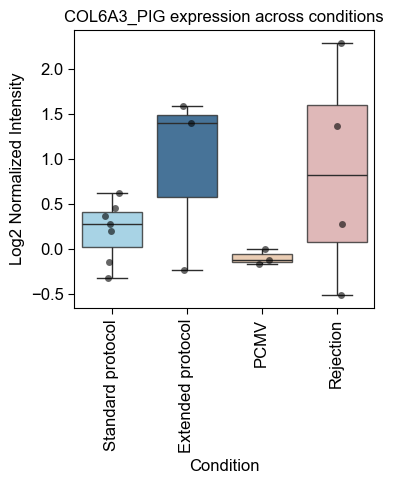

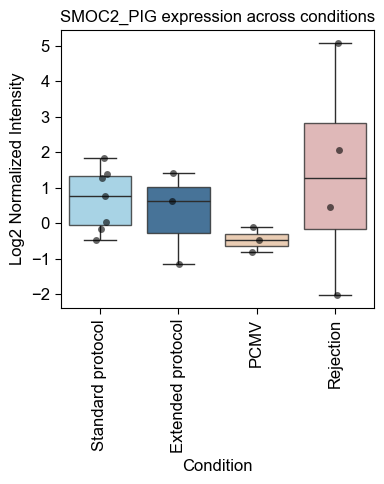

In [7]:
# Example usage:
# plot_gene("IFITM1_PAPAN")
# plot_gene("IFI44_PAPAN")
# plot_gene("IFIT5_PAPAN")
# plot_gene("RIGI_PAPAN")

plot_gene("COL6A3_PIG")
plot_gene("SMOC2_PIG")
# plot_gene("OAS3_PAPAN")
# plot_gene("VCAN_PAPAN")




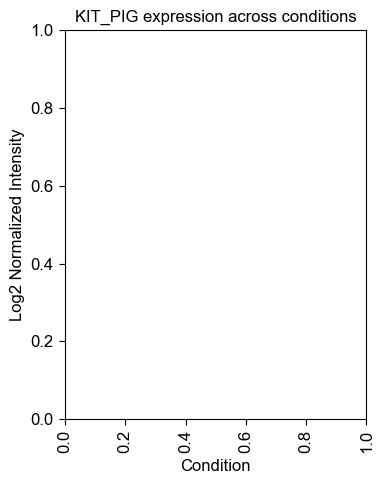

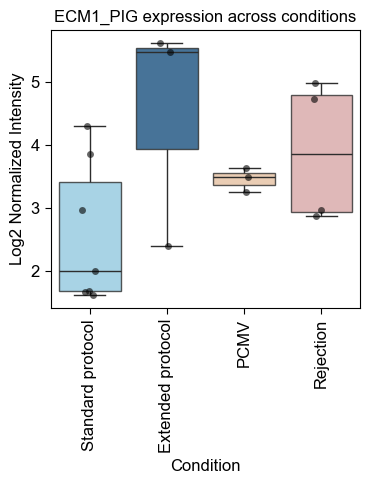

In [17]:
# plot_gene("COL1A1_PAPAN")
# plot_gene("TIMP1_PAPAN")
# plot_gene("COL1A2_PAPAN")
# plot_gene("COL3A1_PAPAN")
# plot_gene("COL6A1_PIG")

plot_gene("KIT_PIG")
plot_gene("ECM1_PIG")


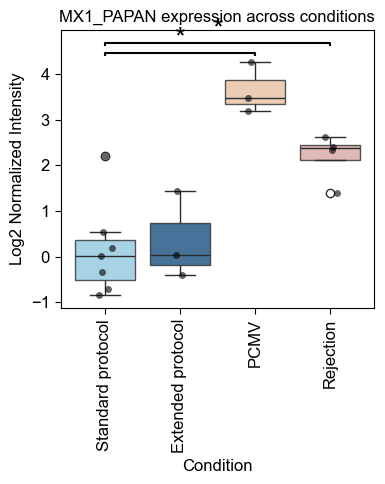

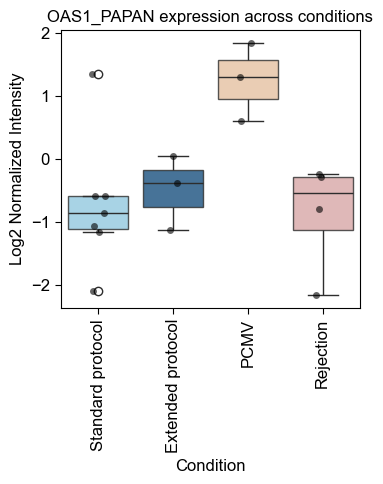

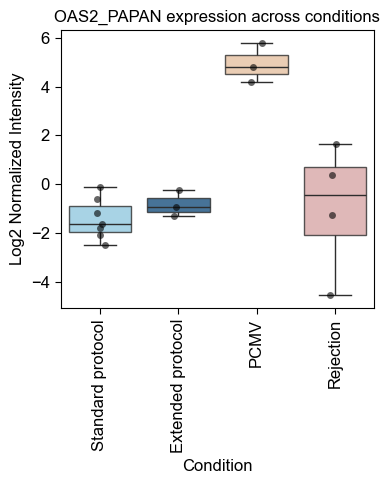

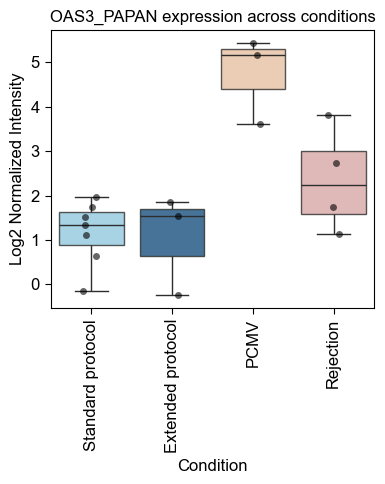

In [6]:
# Example usage:
plot_gene("MX1_PAPAN")
# plot_gene("SERPINE1_PAPAN")
# plot_gene("VWF_PAPAN")
# plot_gene("SLC16A3_PAPAN")

plot_gene("OAS1_PAPAN")
plot_gene("OAS2_PAPAN")
plot_gene("OAS3_PAPAN")
# plot_gene("VCAN_PAPAN")




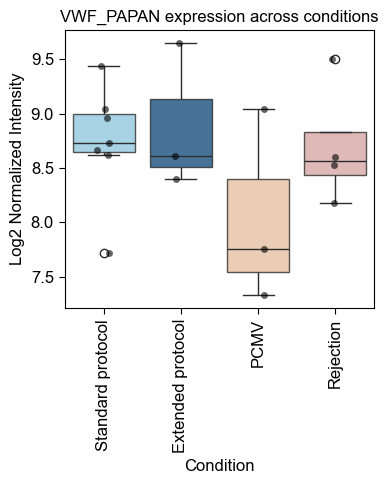

In [9]:
# Example usage:
# plot_gene("CACNA2D1_PAPAN")
# plot_gene("CALML3_PAPAN")
# plot_gene("CALD1_PAPAN")


plot_gene("VWF_PAPAN")
# plot_gene("CANX_PAPAN")
# plot_gene("CAPN1_PAPAN")
# plot_gene("CAPN2_PAPAN")
# plot_gene("CAPN3_PAPAN")
# plot_gene("CAPN5_PAPAN")
# plot_gene("CAST_PAPAN")
# plot_gene("CAPG_PAPAN")
# plot_gene("BST1_PAPAN")

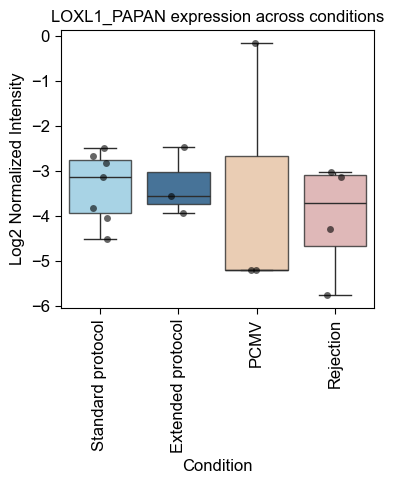

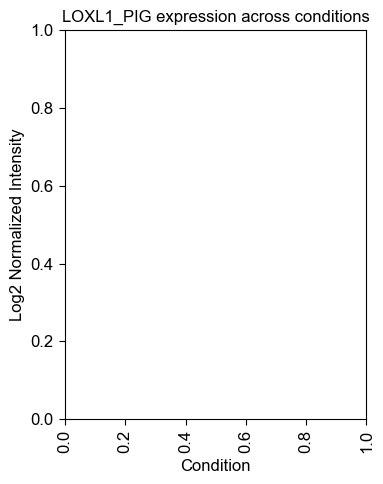

In [15]:
plot_gene("LOXL1_PAPAN")
plot_gene("LOXL1_PIG")

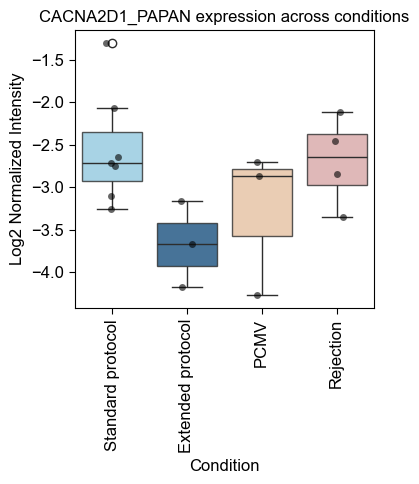

In [28]:
# plot_gene("EGFR_PAPAN")
# plot_gene("ACE2_PAPAN")
plot_gene("CACNA2D1_PAPAN")

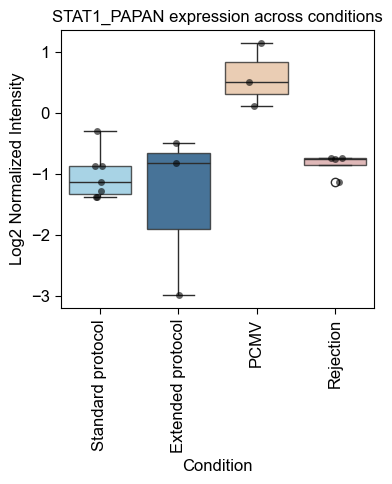

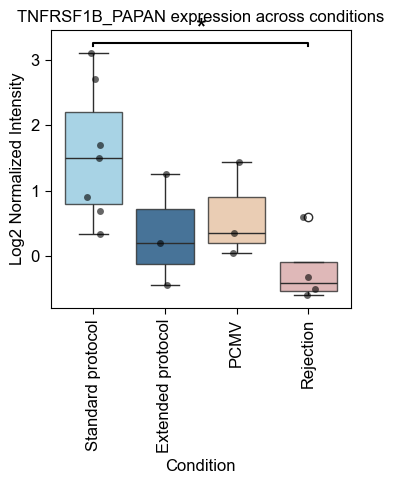

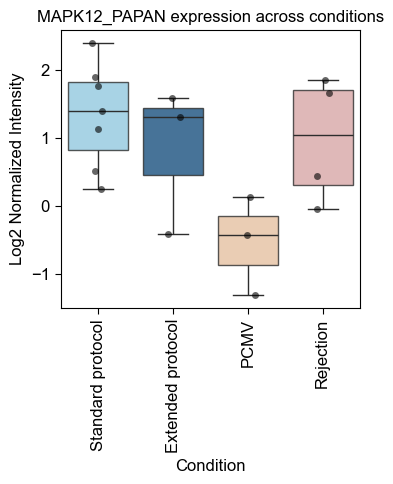

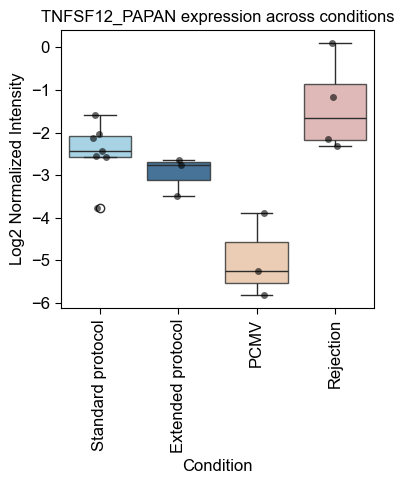

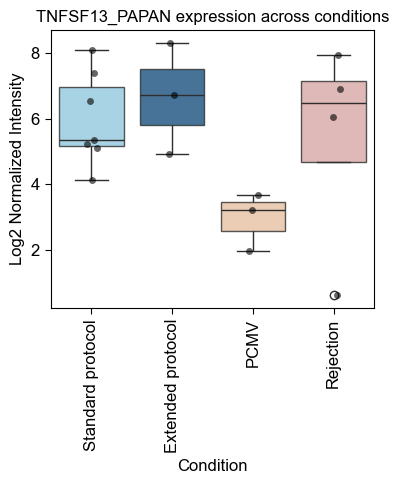

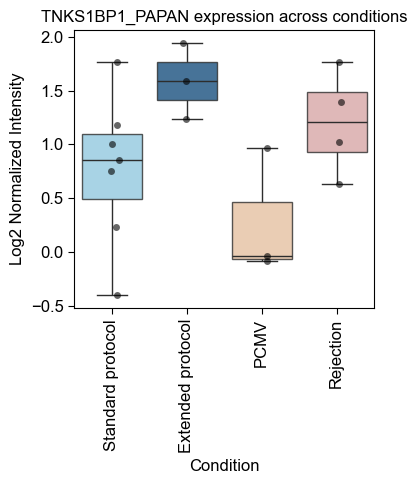

In [125]:
plot_gene("STAT1_PAPAN")
plot_gene("TNFRSF1B_PAPAN")
plot_gene("MAPK12_PAPAN")

plot_gene("TNFSF12_PAPAN")
plot_gene("TNFSF13_PAPAN")
plot_gene("TNKS1BP1_PAPAN")


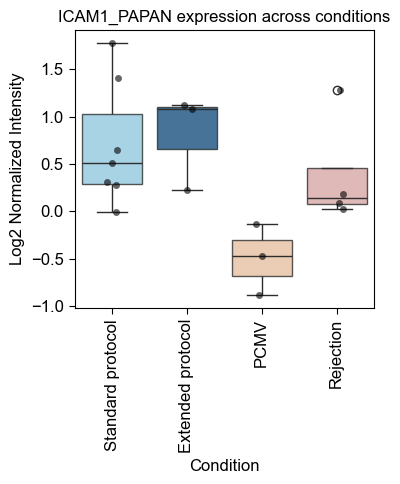

In [178]:

plot_gene("ICAM1_PAPAN")

# plot_gene("MMP9_PAPAN")

# plot_gene("MMP19_PAPAN")

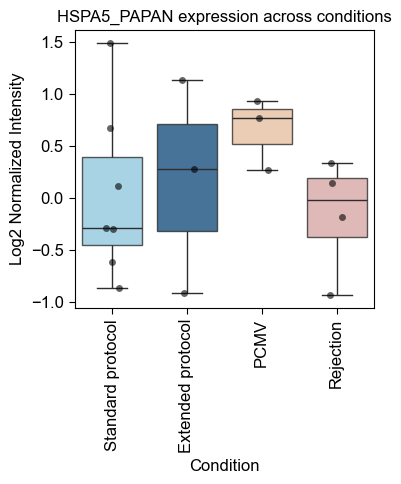

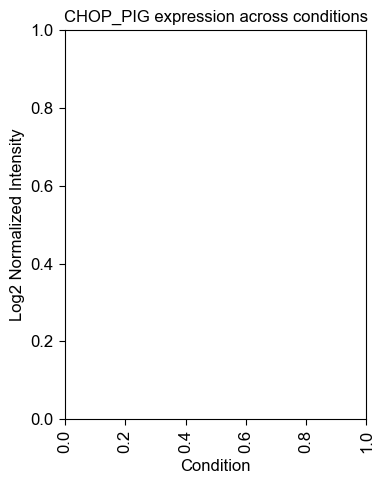

In [8]:

plot_gene("HSPA5_PAPAN")

plot_gene("CHOP_PIG")


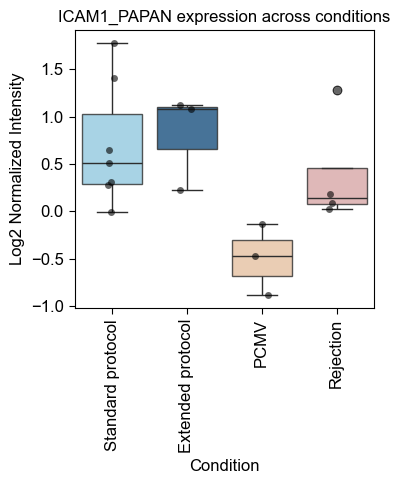

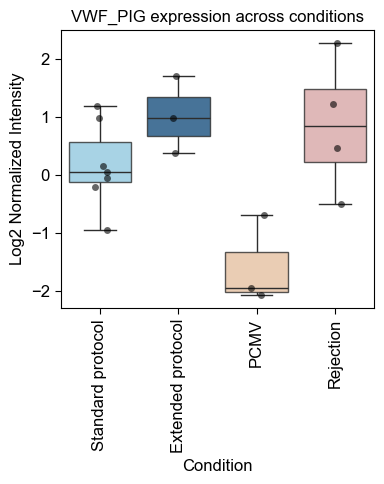

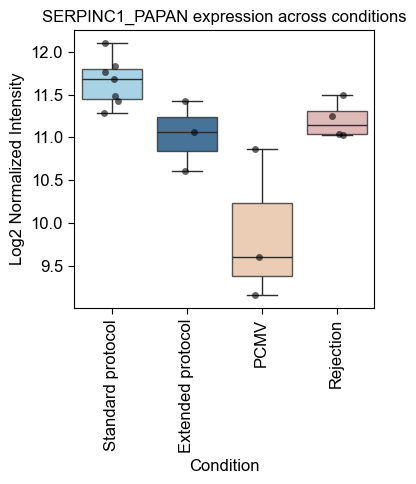

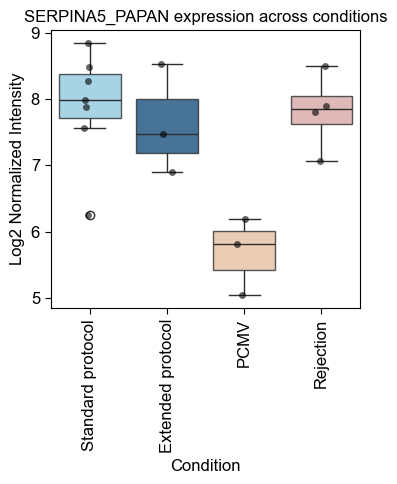

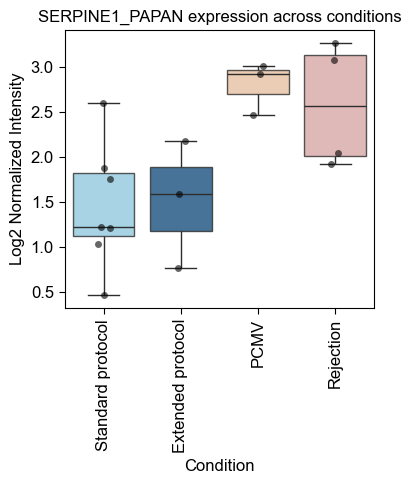

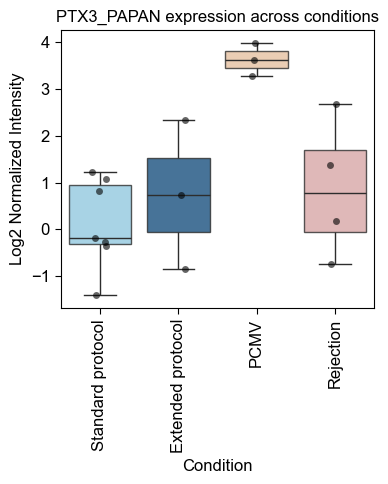

In [167]:
# Endothelial dysfunction

plot_gene("ICAM1_PAPAN")
plot_gene("VWF_PIG")
# plot_gene("SELE_PAPAN")
# plot_gene("SELP_PAPAN")
plot_gene("SERPINC1_PAPAN")
plot_gene("SERPINA5_PAPAN")


# Maladaptive and inflammatory remodelling 

plot_gene("SERPINE1_PAPAN")
plot_gene("PTX3_PAPAN")

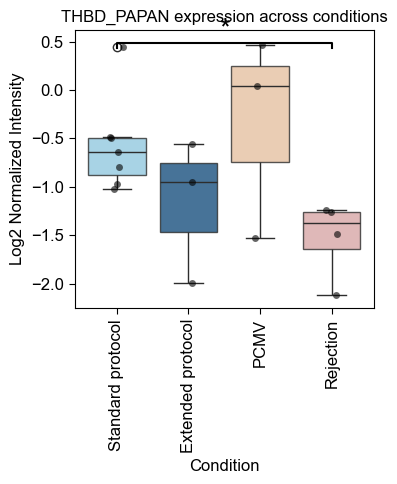

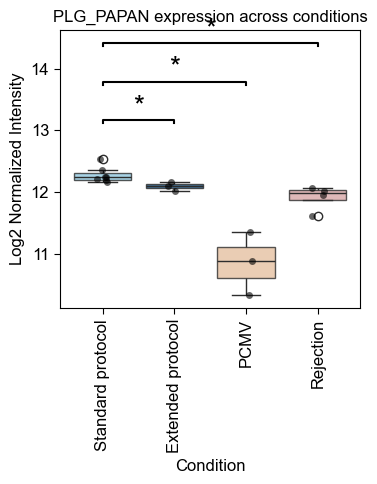

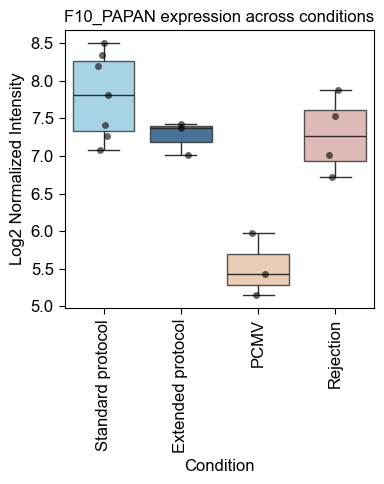

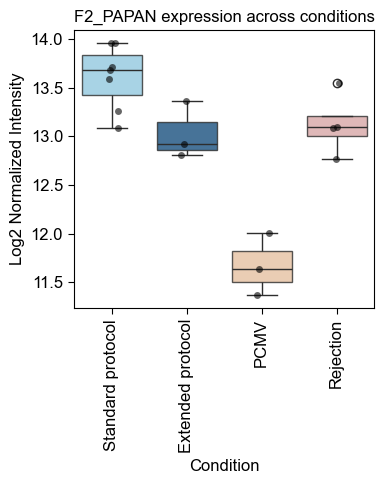

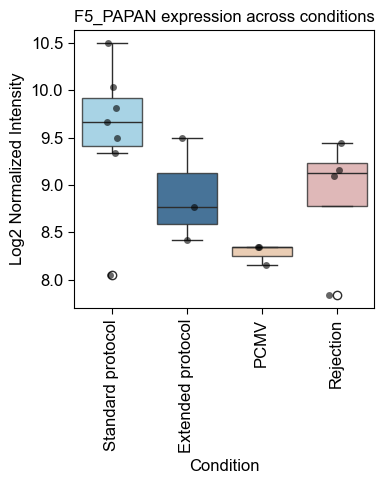

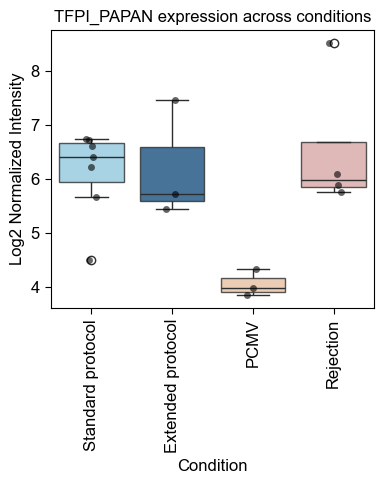

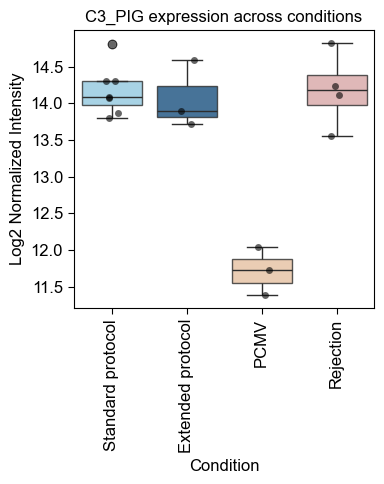

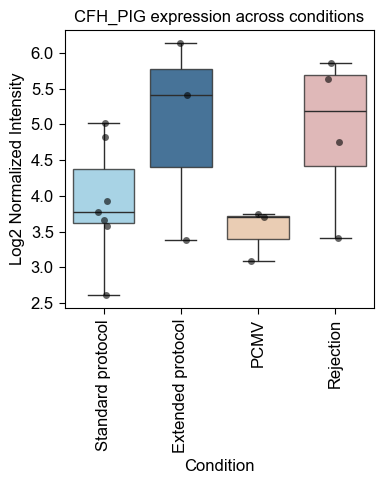

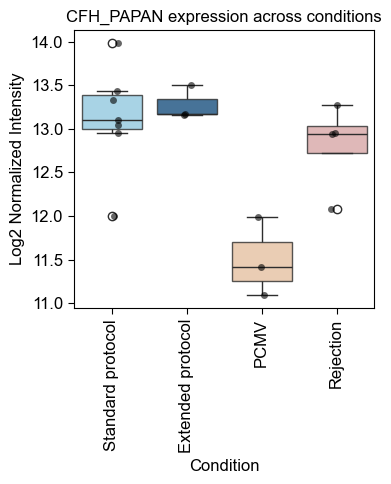

In [169]:
# Endothelial dysfunction - Protein C pathway

# THBD is an endothelial anticoagulant receptor that binds thrombin and converts it from a pro-coagulant to an activator of Protein C.
# Activated Protein C (APC) then reduces thrombin generation, protects endothelium, and has anti-inflammatory and anti-apoptotic effects.
# In short: Lower circulating THBD (or lower endothelial THBD expression) = loss of anticoagulant/anti-inflammatory tone → endothelial dysfunction → microvascular thrombosis and inflammation.


plot_gene("THBD_PAPAN")
# plot_gene("PROC_PAPAN")
# plot_gene("PROCR_PAPAN")
plot_gene("PLG_PAPAN")
plot_gene("F10_PAPAN")
plot_gene("F2_PAPAN")
plot_gene("F5_PAPAN")
plot_gene("TFPI_PAPAN")
# plot_gene("THBS1_PAPAN")




plot_gene("C3_PIG")
plot_gene("CFH_PIG")
plot_gene("CFH_PAPAN")

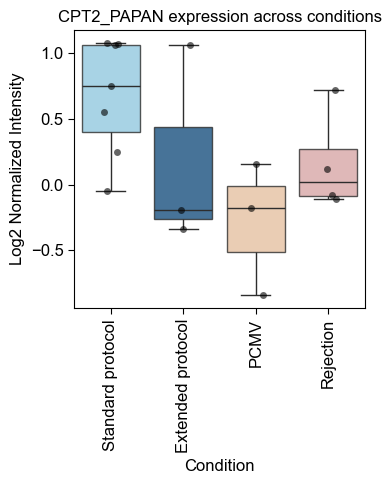

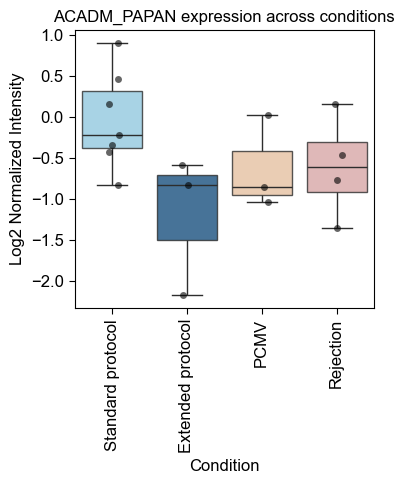

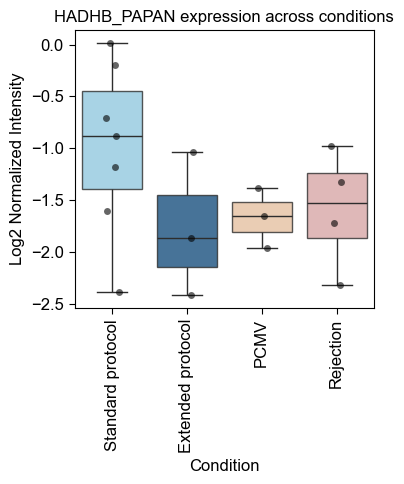

In [106]:
# FAO Metabolism

plot_gene("CPT2_PAPAN")
plot_gene("ACADM_PAPAN")
plot_gene("HADHB_PAPAN")


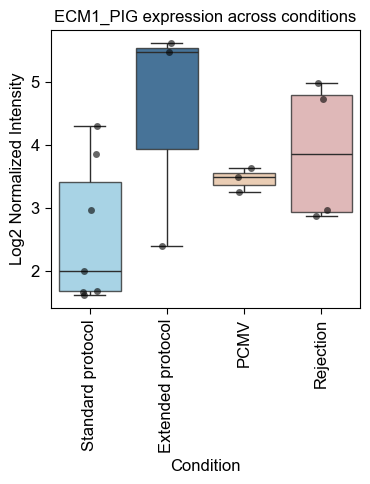

In [58]:
# Ketone Metabolism

plot_gene("ECM1_PIG")
# plot_gene("PFKM_PIG")



In [40]:
import pandas as pd
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests
import os

def perform_differential_expression_and_save_all(df_path):
    """
    Performs differential expression analysis and saves all results
    for each comparison separately.

    Args:
        df_path (str): The file path to the input CSV file.
    """
    # Load the data and prepare metadata
    try:
        df = pd.read_csv(df_path)
    except FileNotFoundError:
        print(f"Error: The file '{df_path}' was not found.")
        print("Please check the file path and try again.")
        return

    sample_cols = [c for c in df.columns if c.startswith("PAV")]

    condition_map = {
        'PAV66': 'Standard protocol', 'PAV82': 'Standard protocol', 'PAV75': 'Standard protocol',
        'PAV78': 'Rejection', 'PAV72': 'Extended protocol', 'PAV85': 'Extended protocol',
        'PAV65': 'Standard protocol', 'PAV76': 'Rejection', 'PAV71': 'Extended protocol',
        'PAV86': 'Rejection', 'PAV68': 'PCMV', 'PAV84': 'Prematurely terminated',
        'PAV73': 'PCMV', 'PAV79': 'Rejection', 'PAV74': 'PCMV',
        'PAV83': 'Prematurely terminated', 'PAV67': 'Standard protocol',
        'PAV69': 'Standard protocol', 'PAV80': 'Standard protocol'
    }
    
    meta = pd.DataFrame({
        "Sample": sample_cols,
        "Condition": [condition_map[s.split("_")[0]] for s in sample_cols]
    })

    # Filter for conditions of interest
    conditions_to_analyze = ['Standard protocol', 'Extended protocol', 'Rejection', 'PCMV']
    meta_filtered = meta[meta['Condition'].isin(conditions_to_analyze)].reset_index(drop=True)
    sample_cols_filtered = meta_filtered['Sample'].tolist()

    all_genes = df['Genes'].tolist()
    comparisons = [
        ('Extended protocol', 'Standard protocol'),
        ('Rejection', 'Standard protocol'),
        ('PCMV', 'Standard protocol')
    ]

    output_dir = "/data2/core-med1/nhadizad/nastaran/Xenotransplant/global/some_R/v2/Results"
    os.makedirs(output_dir, exist_ok=True)

    # Process each comparison separately
    for group1_name, group2_name in comparisons:
        print(f"\nProcessing comparison: {group1_name} vs {group2_name}")
        
        comparison_results = []
        
        for gene in all_genes:
            gene_data = df[df['Genes'] == gene][sample_cols_filtered].T.rename(
                columns={df.index[df['Genes'] == gene].tolist()[0]: 'Log2NormIntensity'}
            )
            gene_data = gene_data.reset_index().rename(columns={'index': 'Sample'})
            gene_data = gene_data.merge(meta_filtered, on='Sample')

            group1_data = gene_data[gene_data['Condition'] == group1_name]['Log2NormIntensity'].dropna()
            group2_data = gene_data[gene_data['Condition'] == group2_name]['Log2NormIntensity'].dropna()

            if len(group1_data) >= 2 and len(group2_data) >= 2:
                try:
                    stat, p_value = mannwhitneyu(group1_data, group2_data, alternative='two-sided')
                    log2fc = group1_data.mean() - group2_data.mean()
                    
                    comparison_results.append({
                        'Gene': gene,
                        'Comparison': f"{group1_name} vs {group2_name}",
                        'Log2FC': log2fc,
                        'p_value': p_value
                    })
                except Exception as e:
                    print(f"Skipping {gene} for this comparison due to error: {e}")
                    
        # Create the results DataFrame and apply FDR correction
        if comparison_results:
            results_df = pd.DataFrame(comparison_results)
            results_df['p_adj'] = multipletests(results_df['p_value'], method='fdr_bh')[1]
            
            # Add Significance column based on criteria
            results_df['Significance'] = 'Not Significant'
            results_df.loc[
                (results_df['p_adj'] < 0.05) & (results_df['Log2FC'].abs() > 0.5),
                'Significance'
            ] = 'Significant'
            
            # Sort all results by Log2FC in descending order
            results_df = results_df.sort_values(by='Log2FC', ascending=False)
            
            # Save all results (no filtering)
            filename = f"{group1_name.replace(' ', '_')}_vs_{group2_name.replace(' ', '_')}_all_results.csv"
            output_file = os.path.join(output_dir, filename)
            results_df.to_csv(output_file, index=False)
            
            print(f"Analysis complete for {group1_name} vs {group2_name}. "
                  f"All results saved to: {output_file}")
            
# --- Usage ---
csv_file_path = "/data2/core-med1/nhadizad/nastaran/Xenotransplant/global/some_R/v2/final_endpoint_samples_info_logNorm.csv"

# Call the function to run the analysis
perform_differential_expression_and_save_all(csv_file_path)


Processing comparison: Extended protocol vs Standard protocol
Analysis complete for Extended protocol vs Standard protocol. All results saved to: /data2/core-med1/nhadizad/nastaran/Xenotransplant/global/some_R/v2/Results/Extended_protocol_vs_Standard_protocol_all_results.csv

Processing comparison: Rejection vs Standard protocol
Analysis complete for Rejection vs Standard protocol. All results saved to: /data2/core-med1/nhadizad/nastaran/Xenotransplant/global/some_R/v2/Results/Rejection_vs_Standard_protocol_all_results.csv

Processing comparison: PCMV vs Standard protocol
Analysis complete for PCMV vs Standard protocol. All results saved to: /data2/core-med1/nhadizad/nastaran/Xenotransplant/global/some_R/v2/Results/PCMV_vs_Standard_protocol_all_results.csv


In [29]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu # Used for Wilcoxon Rank-Sum test
import os
import warnings

# Suppress FutureWarnings that often clutter notebook output
warnings.filterwarnings('ignore', category=FutureWarning)

# --- GLOBAL VARIABLES (from your previous code) ---
# Assuming 'df' and 'meta' DataFrames are loaded in your environment.
# df = pd.read_csv("/data2/core-med1/nhadizad/nastaran/Xenotransplant/global/some_R/v2/final_endpoint_samples_info_logNorm.csv")
# ... (loading and meta definitions assumed) ...
output_dir = "/data2/core-med1/nhadizad/nastaran/Xenotransplant/global/some_R/v2/Results"

COND_ORDER_FOCUSED = [
    "Standard protocol",
    "Extended protocol",
]
COND_PALETTE = {
    "Standard protocol": "skyblue",
    "Extended protocol": "#08528f",
}
# ----------------------------------------------------

def analyze_protein_score(protein_list, score_name):
    """
    Calculates a median protein score, performs Wilcoxon rank-sum test
    between 'Standard protocol' and 'Extended protocol', visualizes the
    result, and saves the plot and statistics.

    Args:
        protein_list (list): List of protein IDs (e.g., ["CPT2_PAPAN", ...]).
        score_name (str): The name to assign to the calculated score (e.g., "FAO_score").
    """
    
    print(f"--- Analyzing Score: {score_name} ---")

    # --- 1. Prepare Data and Calculate Median Score per Sample ---
    present_proteins = [p for p in protein_list if p in df['Genes'].values]
    
    if not present_proteins:
        print(f"ERROR: No proteins from {score_name} found in the data.")
        return

    # Filter data and calculate the MEDIAN score across the protein set for each sample
    protein_df = df[df['Genes'].isin(present_proteins)].set_index('Genes')[sample_cols]
    score_per_sample = protein_df.median(axis=0).rename(score_name).to_frame()

    # Merge score with metadata and filter for the two conditions
    score_per_sample = score_per_sample.merge(
        meta.set_index('Sample'), left_index=True, right_index=True
    )
    plot_data = score_per_sample.rename(columns={score_name: 'Log2NormIntensity'})
    plot_data = plot_data[plot_data['Condition'].isin(COND_ORDER_FOCUSED)]

    if plot_data.empty:
        print("ERROR: No data remaining after filtering for target conditions.")
        return

    # --- 2. Wilcoxon Rank-Sum (Mann-Whitney U) Statistical Testing ---
    group1_name = COND_ORDER_FOCUSED[0]
    group2_name = COND_ORDER_FOCUSED[1]
    
    data1 = plot_data[plot_data['Condition'] == group1_name]['Log2NormIntensity']
    data2 = plot_data[plot_data['Condition'] == group2_name]['Log2NormIntensity']

    stars = ""
    p_value = np.nan
    stat = np.nan
    
    if len(data1) > 1 and len(data2) > 1:
        # Perform the Wilcoxon Rank-Sum test
        stat, p_value = mannwhitneyu(data1, data2, alternative='two-sided')
        
        # Determine significance stars
        if p_value < 0.001:
            stars = "***"
        elif p_value < 0.01:
            stars = "**"
        elif p_value < 0.05:
            stars = "*"
        
        significance = {(group2_name, group1_name): p_value}
        print(f"Wilcoxon p-value: {p_value:.3e}")
    else:
        print("Skipping statistical test: Insufficient data in one or both groups.")

    # --- 3. Visualization (Square Plot) ---
    plt.figure(figsize=(4, 4)) 

    # Box and Stripplots
    sns.boxplot(data=plot_data, x="Condition", y="Log2NormIntensity",
                order=COND_ORDER_FOCUSED, palette=COND_PALETTE, boxprops=dict(alpha=0.8))
    sns.stripplot(data=plot_data, x="Condition", y="Log2NormIntensity", color="black", alpha=0.7,
                  order=COND_ORDER_FOCUSED, size=5)

    # Add significance stars and adjust Y-axis limit to fit annotations
    if stars:
        max_y_data = plot_data['Log2NormIntensity'].max()
        min_y_data = plot_data['Log2NormIntensity'].min()
        y_range = max_y_data - min_y_data
        
        # Define y positions for line and text (inside the plot)
        line_start_y = max_y_data + (0.05 * y_range)
        line_top_y = max_y_data + (0.1 * y_range)
        plot_max_y = max_y_data + (0.25 * y_range) # Extend Y-axis max

        plt.ylim(bottom=min_y_data - (0.05 * y_range), top=plot_max_y)

        x1 = COND_ORDER_FOCUSED.index(group1_name)
        x2 = COND_ORDER_FOCUSED.index(group2_name)
        
        # Add line
        plt.plot([x1, x1, x2, x2], [line_start_y, line_top_y, line_top_y, line_start_y],
                 lw=1.2, c='black')
                 
        # Add text (stars)
        plt.text((x1 + x2) / 2, line_top_y + (0.01 * y_range), stars, ha='center', va='bottom',
                 fontsize=18, color='black')

    # Plot labels
    plt.title(f"Median {score_name} (Std vs Extended)", fontsize=10)
    plt.xlabel("Condition", fontsize=7)
    plt.ylabel(f"Median Log2 Normalized Intensity ({score_name})", fontsize=10)
    plt.xticks(rotation=0, ha='center', fontsize=9)
    plt.yticks(fontsize=9)
    plt.tight_layout()

    # Save Plot
    if not os.path.exists(output_dir): os.makedirs(output_dir)
    plot_filename = f"{output_dir}/{score_name}_StdVsExtended_Median_Square.pdf"
    plt.savefig(plot_filename, dpi=300)
    plt.close()
    print(f"Plot saved to: {plot_filename}")

    # --- 4. Save Statistics to CSV ---
    
    # Calculate group summary statistics
    summary_data = plot_data.groupby('Condition')['Log2NormIntensity'].agg(['median', 'count', 'std'])
    summary_stats_series = {}

    for group in COND_ORDER_FOCUSED:
        group_clean = group.replace(" ", "_")
        summary_stats_series[f'N_{group_clean}'] = summary_data.loc[group, 'count']
        summary_stats_series[f'Median_{group_clean}'] = summary_data.loc[group, 'median']
        summary_stats_series[f'SD_{group_clean}'] = summary_data.loc[group, 'std']

    summary_df = pd.DataFrame([summary_stats_series])

    # Create the core results DataFrame
    stat_results_df = pd.DataFrame({
        'Pathway_Score': [score_name],
        'Comparison': [f"{group2_name} vs {group1_name}"],
        'Test_Used': ['Wilcoxon Rank-Sum (Mann-Whitney U)'],
        'Raw_P_Value': [p_value],
        'Test_Statistic_U': [stat],
        'FDR_Corrected': ['No (Only 1 test performed)'],
        'Proteins_in_Score': ["; ".join(protein_list)],
    })

    # Concatenate: Both DataFrames now have 1 row
    stat_results_df = pd.concat([stat_results_df, summary_df], axis=1)

    # Save CSV
    csv_filename = f"{output_dir}/{score_name}_StdVsExtended_Median_Stats.csv"
    stat_results_df.to_csv(csv_filename, index=False)

    print(f"Statistical results saved to: {csv_filename}")
    print("\nStatistical Summary:")
    print(stat_results_df)

# ===============================================================
# Example Usage: Change the list and name below to analyze any pathway
# ===============================================================

# 1. Define your current list:
fao_proteins_list = [
    "CPT2_PAPAN", "ACADM_PAPAN", "ACADVL_PAPAN", 
    "HADH_PAPAN", "EHHADH_PAPAN", 'ACADS_PAPAN', 
    'HADHB_PAPAN', 'HADHA_PAPAN'
]

# 2. Call the function:
analyze_protein_score(
    protein_list=fao_proteins_list,
    score_name="FAO_Score" # This name will be used in the titles and filenames
)

# You can now easily test another list, e.g., Glycolysis:
# glycolysis_proteins = ["HK2_PAPAN", "PFKM_PAPAN", "PKM_PAPAN", "LDHA_PAPAN"]
# analyze_protein_score(glycolysis_proteins, "Glycolysis_Score")

--- Analyzing Score: FAO_Score ---
Wilcoxon p-value: 1.667e-02
Plot saved to: /data2/core-med1/nhadizad/nastaran/Xenotransplant/global/some_R/v2/Results/FAO_Score_StdVsExtended_Median_Square.pdf
Statistical results saved to: /data2/core-med1/nhadizad/nastaran/Xenotransplant/global/some_R/v2/Results/FAO_Score_StdVsExtended_Median_Stats.csv

Statistical Summary:
  Pathway_Score                              Comparison  \
0     FAO_Score  Extended protocol vs Standard protocol   

                            Test_Used  Raw_P_Value  Test_Statistic_U  \
0  Wilcoxon Rank-Sum (Mann-Whitney U)     0.016667              21.0   

                FDR_Corrected  \
0  No (Only 1 test performed)   

                                   Proteins_in_Score  N_Standard_protocol  \
0  CPT2_PAPAN; ACADM_PAPAN; ACADVL_PAPAN; HADH_PA...                    7   

   Median_Standard_protocol  SD_Standard_protocol  N_Extended_protocol  \
0                  0.101918              0.208108                    3   

  

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu # Used for Wilcoxon Rank-Sum test
import os
import warnings

# Suppress FutureWarnings that often clutter notebook output
warnings.filterwarnings('ignore', category=FutureWarning)

# --- GLOBAL VARIABLES (from your previous code) ---
# Assuming 'df' and 'meta' DataFrames are loaded in your environment.
# df = pd.read_csv("/data2/core-med1/nhadizad/nastaran/Xenotransplant/global/some_R/v2/final_endpoint_samples_info_logNorm.csv")
# ... (loading and meta definitions assumed) ...
output_dir = "/data2/core-med1/nhadizad/nastaran/Xenotransplant/global/some_R/v2/Results"

COND_ORDER_FOCUSED = [
    "Standard protocol",
    "Extended protocol",
]
COND_PALETTE = {
    "Standard protocol": "skyblue",
    "Extended protocol": "#08528f",
}
# ----------------------------------------------------

def analyze_protein_score(protein_list, score_name):
    """
    Calculates a median protein score, performs Wilcoxon rank-sum test
    between 'Standard protocol' and 'Extended protocol', visualizes the
    result, and saves the plot and statistics.

    Args:
        protein_list (list): List of protein IDs (e.g., ["CPT2_PAPAN", ...]).
        score_name (str): The name to assign to the calculated score (e.g., "FAO_score").
    """
    
    print(f"--- Analyzing Score: {score_name} ---")

    # --- 1. Prepare Data and Calculate Median Score per Sample ---
    present_proteins = [p for p in protein_list if p in df['Genes'].values]
    
    if not present_proteins:
        print(f"ERROR: No proteins from {score_name} found in the data.")
        return

    # Filter data and calculate the MEDIAN score across the protein set for each sample
    protein_df = df[df['Genes'].isin(present_proteins)].set_index('Genes')[sample_cols]
    score_per_sample = protein_df.median(axis=0).rename(score_name).to_frame()

    # Merge score with metadata and filter for the two conditions
    score_per_sample = score_per_sample.merge(
        meta.set_index('Sample'), left_index=True, right_index=True
    )
    plot_data = score_per_sample.rename(columns={score_name: 'Log2NormIntensity'})
    plot_data = plot_data[plot_data['Condition'].isin(COND_ORDER_FOCUSED)]

    if plot_data.empty:
        print("ERROR: No data remaining after filtering for target conditions.")
        return

    # --- 2. Wilcoxon Rank-Sum (Mann-Whitney U) Statistical Testing ---
    group1_name = COND_ORDER_FOCUSED[0]
    group2_name = COND_ORDER_FOCUSED[1]
    
    data1 = plot_data[plot_data['Condition'] == group1_name]['Log2NormIntensity']
    data2 = plot_data[plot_data['Condition'] == group2_name]['Log2NormIntensity']

    stars = ""
    p_value = np.nan
    stat = np.nan
    
    if len(data1) > 1 and len(data2) > 1:
        # Perform the Wilcoxon Rank-Sum test
        stat, p_value = mannwhitneyu(data1, data2, alternative='two-sided')
        
        # Determine significance stars
        if p_value < 0.001:
            stars = "***"
        elif p_value < 0.01:
            stars = "**"
        elif p_value < 0.05:
            stars = "*"
        
        significance = {(group2_name, group1_name): p_value}
        print(f"Wilcoxon p-value: {p_value:.3e}")
    else:
        print("Skipping statistical test: Insufficient data in one or both groups.")

    # --- 3. Visualization (Square Plot) ---
    plt.figure(figsize=(4, 4)) 

    # Box and Stripplots
    sns.boxplot(data=plot_data, x="Condition", y="Log2NormIntensity",
                order=COND_ORDER_FOCUSED, palette=COND_PALETTE, boxprops=dict(alpha=0.8))
    sns.stripplot(data=plot_data, x="Condition", y="Log2NormIntensity", color="black", alpha=0.7,
                  order=COND_ORDER_FOCUSED, size=5)

    # Add significance stars and adjust Y-axis limit to fit annotations
    if stars:
        max_y_data = plot_data['Log2NormIntensity'].max()
        min_y_data = plot_data['Log2NormIntensity'].min()
        y_range = max_y_data - min_y_data
        
        # Define y positions for line and text (inside the plot)
        line_start_y = max_y_data + (0.05 * y_range)
        line_top_y = max_y_data + (0.1 * y_range)
        plot_max_y = max_y_data + (0.25 * y_range) # Extend Y-axis max

        plt.ylim(bottom=min_y_data - (0.05 * y_range), top=plot_max_y)

        x1 = COND_ORDER_FOCUSED.index(group1_name)
        x2 = COND_ORDER_FOCUSED.index(group2_name)
        
        # Add line
        plt.plot([x1, x1, x2, x2], [line_start_y, line_top_y, line_top_y, line_start_y],
                 lw=1.2, c='black')
                 
        # Add text (stars)
        plt.text((x1 + x2) / 2, line_top_y + (0.01 * y_range), stars, ha='center', va='bottom',
                 fontsize=18, color='black')

    # Plot labels
    plt.title(f"Median {score_name} (Std vs Extended)", fontsize=10)
    plt.xlabel("Condition", fontsize=7)
    plt.ylabel(f"Median Log2 Normalized Intensity ({score_name})", fontsize=10)
    plt.xticks(rotation=0, ha='center', fontsize=9)
    plt.yticks(fontsize=9)
    plt.tight_layout()

    # Save Plot
    if not os.path.exists(output_dir): os.makedirs(output_dir)
    plot_filename = f"{output_dir}/{score_name}_StdVsExtended_Median_Square.pdf"
    plt.savefig(plot_filename, dpi=300)
    plt.close()
    print(f"Plot saved to: {plot_filename}")

    # --- 4. Save Statistics to CSV ---
    
    # Calculate group summary statistics
    summary_data = plot_data.groupby('Condition')['Log2NormIntensity'].agg(['median', 'count', 'std'])
    summary_stats_series = {}

    for group in COND_ORDER_FOCUSED:
        group_clean = group.replace(" ", "_")
        summary_stats_series[f'N_{group_clean}'] = summary_data.loc[group, 'count']
        summary_stats_series[f'Median_{group_clean}'] = summary_data.loc[group, 'median']
        summary_stats_series[f'SD_{group_clean}'] = summary_data.loc[group, 'std']

    summary_df = pd.DataFrame([summary_stats_series])

    # Create the core results DataFrame
    stat_results_df = pd.DataFrame({
        'Pathway_Score': [score_name],
        'Comparison': [f"{group2_name} vs {group1_name}"],
        'Test_Used': ['Wilcoxon Rank-Sum (Mann-Whitney U)'],
        'Raw_P_Value': [p_value],
        'Test_Statistic_U': [stat],
        'FDR_Corrected': ['No (Only 1 test performed)'],
        'Proteins_in_Score': ["; ".join(protein_list)],
    })

    # Concatenate: Both DataFrames now have 1 row
    stat_results_df = pd.concat([stat_results_df, summary_df], axis=1)

    # Save CSV
    csv_filename = f"{output_dir}/{score_name}_StdVsExtended_Median_Stats.csv"
    stat_results_df.to_csv(csv_filename, index=False)

    print(f"Statistical results saved to: {csv_filename}")
    print("\nStatistical Summary:")
    print(stat_results_df)

# ===============================================================
# Example Usage: Change the list and name below to analyze any pathway
# ===============================================================

# 1. Define your current list:
glycolysis_proteins_list = [
    "CPT2_PAPAN", "ACADM_PAPAN", "ACADVL_PAPAN", 
    "HADH_PAPAN", "EHHADH_PAPAN", 'ACADS_PAPAN', 
    'HADHB_PAPAN', 'HADHA_PAPAN'
]

# 2. Call the function:
analyze_protein_score(
    protein_list=glycolysis_proteins_list,
    score_name="glycolysis_Score" # This name will be used in the titles and filenames
)

# You can now easily test another list, e.g., Glycolysis:
# glycolysis_proteins = ["HK2_PAPAN", "PFKM_PAPAN", "PKM_PAPAN", "LDHA_PAPAN"]
# analyze_protein_score(glycolysis_proteins, "Glycolysis_Score")